In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
np.random.seed(42)

In [5]:
df = pd.read_csv('../datasets/synthetic_linear_data.csv')
X = df[['X']].values
y = df[['y']].values

In [6]:
df.head()


,X,y
0,0.749080,6.334288
1,1.901429,9.405278
2,1.463988,8.483724
3,1.197317,5.604382
4,0.312037,4.716440


In [7]:
df.describe()

,X,y
count,100.000000,100.000000
mean,0.940361,6.820004
std,0.594979,1.879138
min,0.011044,3.238062
25%,0.386402,5.302794
50%,0.928285,6.676056
75%,1.460406,8.297638
max,1.973774,11.044395


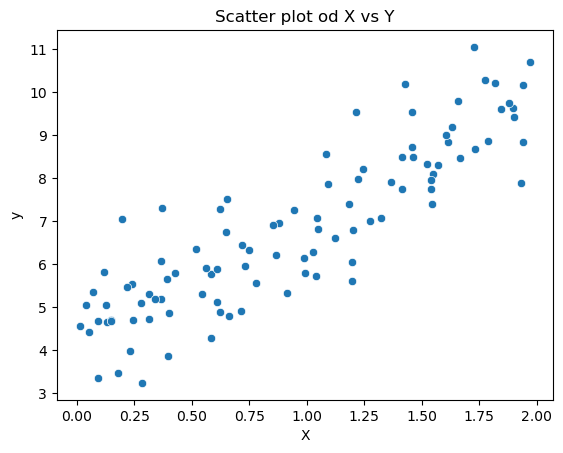

In [8]:
sns.scatterplot(x="X", y="y", data = df)
plt.title("Scatter plot od X vs Y")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [10]:
def compute_cost(X,y,w,b):
    n = len(y)
    y_pred = w * X + b
    cost = (1 / n) * np.sum((y_pred - y) ** 2)
    return cost

In [11]:
def compute_gradients(X,y,w,b):
    n = len(y)
    y_pred = w * X + b

    dw = (2 / n) * np.sum((y_pred - y) * X)
    db = (2 / n) * np.sum(y_pred - y)

    return dw, db
    

In [12]:
def gradient_descent(X, y, w, b, lr=0.01, epochs = 1000):
    cost_history = []

    for _ in range(epochs):
        dw, db = compute_gradients(X, y, w, b)
        w -= lr * dw
        b -= lr * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

In [14]:
w_init = 0
b_init = 0

w,b,cost_history = gradient_descent(
    X_train.flatten(),
    y_train.flatten(),
    w_init,
    b_init,
    lr=0.01,
    epochs=1000
)

print("Learned w:", w)
print("Learned b:", b)



Learned w: 2.829058820123641
Learned b: 4.1095554202449875


In [16]:
y_pred_custom = w * X_test + b
y_pred_custom

array([[4.46917604],
       [9.17259384],
       [8.47900717],
       [7.85818444],
       [5.573763  ],
       [6.59999001],
       [5.76254421],
       [8.99309614],
       [4.22602491],
       [6.22874747],
       [6.55355115],
       [7.54711566],
       [8.72353211],
       [9.47846142],
       [4.78623373],
       [4.99232724],
       [8.47349377],
       [4.52850877],
       [8.81961381],
       [5.07440097]])

In [17]:
mse_custom = mean_squared_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)

print("Custom MSE:", mse_custom)
print("Custom R2:", r2_custom)

Custom MSE: 0.6595295175508236
Custom R2: 0.8054865345109443


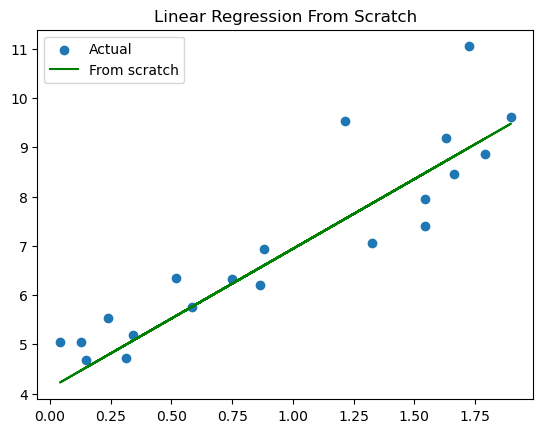

In [18]:
plt.scatter(X_test, y_test, label = "Actual")
plt.plot(X_test, y_pred_custom, color="green", label="From scratch")
plt.legend()
plt.title("Linear Regression From Scratch")
plt.show()


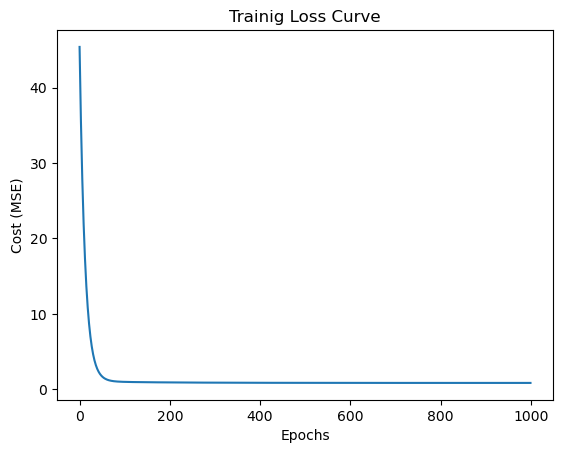

In [19]:
plt.plot(cost_history)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Trainig Loss Curve")
plt.show()

In [20]:
#cost is decresing hence we know that gradient descent is working